In [309]:
'''
Names: Prashant Ram, Muhammed Hassan
Course: CSC 177
Assignment: 4 - Cluster Analysis, ANN, Text Mining
Professor: Jagannadha Chidella
Details: 
'''

import pandas
import matplotlib.pyplot as matPlot
from IPython.display import HTML, display
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import FunctionTransformer
from scipy.cluster.hierarchy import dendrogram, linkage

In [310]:
display(HTML("<h2><strong>Doing Some Preprocessing...</strong></h2>"))

'''
This block reads the data from a .csv file and makes columns for the data
'''
try:
    # import the data from the .csv file. "data" = dataframe. Our data is using ; as a separator and quotes to enclose
    # the data. The first row is the header row so we use the correct separator and quote character or else pandas treats these
    # data as a single column which we don't want.
    data = pandas.read_csv('imdb_dataset.csv')

    #print the data attribute columns
    print(data.columns)
        
    # print the number of rows and columns
    print(f'We have {data.shape[0]} rows')
    print(f'We have {data.shape[1]} columns')

    # print the first 5 rows of the data
    print('\n', data.head())
    
except Exception as e:
    print("An error occured while trying to read from the CSV file", e)

Index(['Unnamed: 0', 'title', 'title_type', 'genre', 'runtime', 'mpaa_rating',
       'studio', 'thtr_rel_year', 'thtr_rel_month', 'thtr_rel_day',
       'dvd_rel_year', 'dvd_rel_month', 'dvd_rel_day', 'imdb_rating',
       'imdb_num_votes', 'critics_rating', 'critics_score', 'audience_rating',
       'audience_score', 'best_pic_nom', 'best_pic_win', 'best_actor_win',
       'best_actress_win', 'best_dir_win', 'top200_box', 'director', 'actor1',
       'actor2', 'actor3', 'actor4', 'actor5', 'imdb_url', 'rt_url'],
      dtype='object')
We have 651 rows
We have 33 columns

    Unnamed: 0                 title    title_type   genre  runtime  \
0           1           Filly Brown  Feature Film   Drama     80.0   
1           2              The Dish  Feature Film   Drama    101.0   
2           3   Waiting for Guffman  Feature Film  Comedy     84.0   
3           4  The Age of Innocence  Feature Film   Drama    139.0   
4           5           Malevolence  Feature Film  Horror     90.0   


In [311]:
'''
This block drops all rows and columns with missing data
'''
# print the number of rows and columns
original_rows = data.shape[0]
original_columns = data.shape[1]
print(f'We have {original_rows} [original] rows and {original_columns} columns')
print('\nOriginal Data:', data.head())
    
#drops all rows with no data
data = data.dropna()

clean_rows = data.shape[0]
clean_columns = data.shape[1]
print(f'\nWe have {clean_rows} [Clean] rows and {clean_columns} columns')
print('\nCleaned data Data:', data.head())

print(f'\n\nWe had {original_rows - clean_rows} rows and {original_columns - clean_columns} columns of missing data')

We have 651 [original] rows and 33 columns

Original Data:    Unnamed: 0                 title    title_type   genre  runtime  \
0           1           Filly Brown  Feature Film   Drama     80.0   
1           2              The Dish  Feature Film   Drama    101.0   
2           3   Waiting for Guffman  Feature Film  Comedy     84.0   
3           4  The Age of Innocence  Feature Film   Drama    139.0   
4           5           Malevolence  Feature Film  Horror     90.0   

  mpaa_rating                    studio  thtr_rel_year  thtr_rel_month  \
0           R       Indomina Media Inc.           2013               4   
1       PG-13     Warner Bros. Pictures           2001               3   
2           R    Sony Pictures Classics           1996               8   
3          PG         Columbia Pictures           1993              10   
4           R  Anchor Bay Entertainment           2004               9   

   thtr_rel_day  ...  best_dir_win  top200_box           director  \
0     

In [312]:
'''This block checks for duplicate rows and drops the ones that are duplicates'''
total_duplicates = data.duplicated().sum()

if total_duplicates != 0:
    data = data.drop_duplicates(inkeep='first')
    print(f"\nThere were {total_duplicates} duplicate rows in the data set.")
else:
    print("\nThere were no duplicate rows in the data set.")



There were no duplicate rows in the data set.


In [313]:
# we will drop the columns that are not needed for the analysis

#drop that first unname column
data = data.drop(data.columns[0], axis=1)
#drop the remaing columns that are not needed for the analysis
data = data.drop(['actor1', 'actor2', 'actor3', 'actor4', 'actor5', 'imdb_url', 'rt_url'], axis=1)
#print the data types of each remaining column
print(data.dtypes)

title                object
title_type           object
genre                object
runtime             float64
mpaa_rating          object
studio               object
thtr_rel_year         int64
thtr_rel_month        int64
thtr_rel_day          int64
dvd_rel_year        float64
dvd_rel_month       float64
dvd_rel_day         float64
imdb_rating         float64
imdb_num_votes        int64
critics_rating       object
critics_score         int64
audience_rating      object
audience_score        int64
best_pic_nom         object
best_pic_win         object
best_actor_win       object
best_actress_win     object
best_dir_win         object
top200_box           object
director             object
dtype: object


In [314]:
#preprocessing continues 

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer as Si
from sklearn.preprocessing import StandardScaler as Stdscaler, OneHotEncoder as OHE
from sklearn.compose import ColumnTransformer

#converting catergorical data to numerical data
#replace all 'no' with 0 and 'yes' with 1
cols = ['best_pic_nom', 'best_pic_win', 'best_actor_win', 'best_actress_win', 'best_dir_win', 'top200_box']
data[cols] = data[cols].replace({'no': 0, 'yes': 1})

#get all the numric features
numeric_features = ['runtime', 'thtr_rel_year', 'thtr_rel_month','thtr_rel_day','dvd_rel_year','dvd_rel_month', 'dvd_rel_day', 'imdb_rating', 
                    'imdb_num_votes', 'critics_score', 'audience_score']

#get all categorical features
catergorical_features = ['title_type',	'genre', 'mpaa_rating', 'studio', 'critics_rating', 'audience_rating']

#create a numeric pipeline
numeric_pipeline = Pipeline([('impute', Si(strategy='median')), ('scale', Stdscaler())])
#create a categorical pipeline
categoric_pipeline = Pipeline([('impute', Si(strategy='most_frequent', fill_value='missing')), ('encode', OHE(handle_unknown='ignore'))])

#combine the numeric and categorical pipelines into a single pipeline
combined_pipeline = ColumnTransformer([('numeric', numeric_pipeline, numeric_features), ('categoric', categoric_pipeline, catergorical_features)])

#lets see the columns - to verify they got added with the one hot encoder
print(data.columns)
#and the changed values
print(data.head())

#fit the data so the model can learn
fitted_data = combined_pipeline.fit_transform(data)


Index(['title', 'title_type', 'genre', 'runtime', 'mpaa_rating', 'studio',
       'thtr_rel_year', 'thtr_rel_month', 'thtr_rel_day', 'dvd_rel_year',
       'dvd_rel_month', 'dvd_rel_day', 'imdb_rating', 'imdb_num_votes',
       'critics_rating', 'critics_score', 'audience_rating', 'audience_score',
       'best_pic_nom', 'best_pic_win', 'best_actor_win', 'best_actress_win',
       'best_dir_win', 'top200_box', 'director'],
      dtype='object')
                  title    title_type   genre  runtime mpaa_rating  \
0           Filly Brown  Feature Film   Drama     80.0           R   
1              The Dish  Feature Film   Drama    101.0       PG-13   
2   Waiting for Guffman  Feature Film  Comedy     84.0           R   
3  The Age of Innocence  Feature Film   Drama    139.0          PG   
4           Malevolence  Feature Film  Horror     90.0           R   

                     studio  thtr_rel_year  thtr_rel_month  thtr_rel_day  \
0       Indomina Media Inc.           2013            

C:\Users\rampr\AppData\Local\Temp\ipykernel_58644\2837275663.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data[cols] = data[cols].replace({'no': 0, 'yes': 1})


SSE values for each value of K:
---------------------------------
k = 1 : 7515.799183268949
k = 2 : 6976.374769954925
k = 3 : 6677.060921684989
k = 4 : 6275.85616041172
k = 5 : 6005.456720383056
k = 6 : 5843.117310185213
k = 7 : 5673.297342534633
k = 8 : 5550.99861470696
k = 9 : 5439.180275825365
k = 10 : 5338.913572141965
k = 11 : 5213.4654363151585
k = 12 : 5166.697065817094


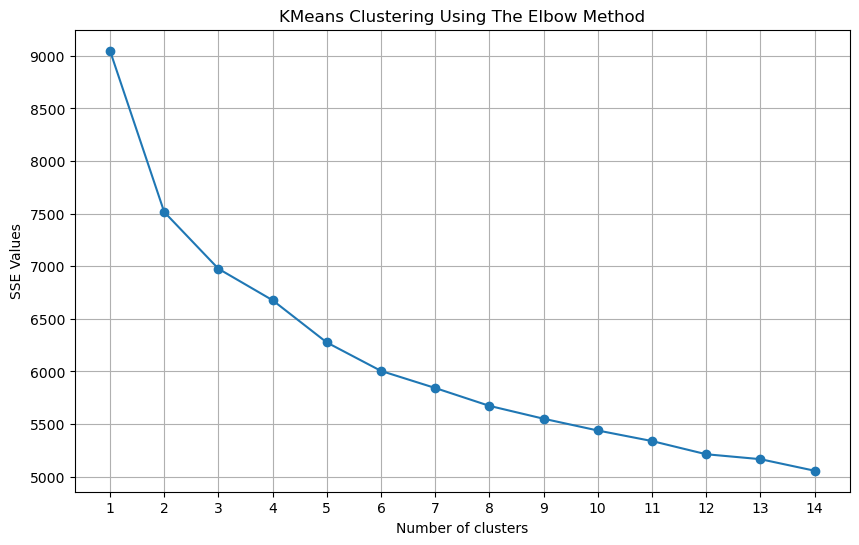

In [ ]:
display(HTML("<h1><strong>Part 1 : Clustering</strong></h1>"))
display(HTML("<h2><strong>KMEANS Clustering</strong></h2>"))
# KMEANS clutering
from sklearn.cluster import KMeans

#this will hold the different SSE values for each value of k
cluster_Kmeans = [] 

#findiing the optimal value for k for clustering for KMEANS
print('SSE values for each value of K:')
print('-------------------------------')
for i in range(1, 15):
    kmeans = KMeans(n_clusters = i, random_state = 42)
    kmeans.fit(fitted_data)
    cluster_Kmeans.append(kmeans.inertia_)

#print the results for us to see
for i in range(1, len(cluster_Kmeans)-1):
    print(f"k = {i} : {cluster_Kmeans[i]}")

#plot the data
matPlot.figure(figsize=(10, 6))
matPlot.plot(range(1, 15), cluster_Kmeans, marker='o')
matPlot.title('KMeans Clustering Using The Elbow Method')
matPlot.xlabel('Number of clusters')
matPlot.ylabel('SSE Values')
matPlot.xticks(range(1, 15))
matPlot.grid()
matPlot.show()

In [316]:
#from the data, k= 3,4 seems optimal since we see that "knee/elbow" over there. We'll use 4

k = 4

# build the pipeline for KMEANS using k = 4
kmeans_pipeline = Pipeline([
                            ('preprocess', combined_pipeline),
                            ('kmeans', KMeans(n_clusters = k, random_state = 42))])

# fitting and predicting simulataneously
data['cluster_kmeans'] = kmeans_pipeline.fit_predict(data)

# inspect cluster sizes
print(f"Cluster sizes: {data['cluster_kmeans'].value_counts()}\n\n")

display(HTML('<h2>KMEANS Results On Dataset</h2>'))
#print the rows with cluster labels
print(data[['title', 'genre', 'runtime', 'imdb_num_votes', 'cluster_kmeans']].head())




Cluster sizes: cluster_kmeans
1    196
0    148
3    147
2    128
Name: count, dtype: int64




                  title   genre  runtime  imdb_num_votes  cluster_kmeans
0           Filly Brown   Drama     80.0             899               3
1              The Dish   Drama    101.0           12285               1
2   Waiting for Guffman  Comedy     84.0           22381               1
3  The Age of Innocence   Drama    139.0           35096               1
4           Malevolence  Horror     90.0            2386               2


In [317]:
from IPython.display import HTML, display

display(HTML('<h1>Hierarchial Clustering</h1>'))

Cluster sizes: cluster_hierarchial
3    187
1    152
0    144
2    136
Name: count, dtype: int64



                  title   genre  runtime  imdb_num_votes  cluster_hierarchial
0           Filly Brown   Drama     80.0             899                    1
1              The Dish   Drama    101.0           12285                    2
2   Waiting for Guffman  Comedy     84.0           22381                    2
3  The Age of Innocence   Drama    139.0           35096                    2
4           Malevolence  Horror     90.0            2386                    1


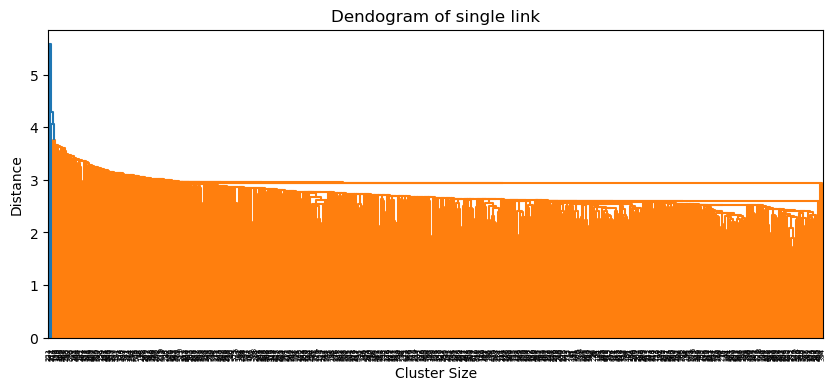

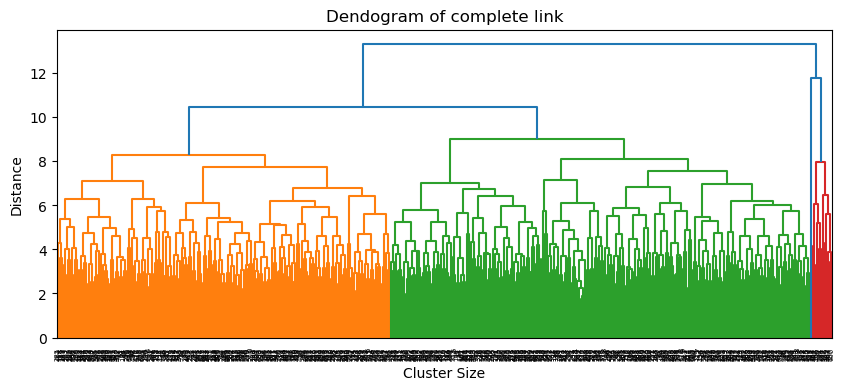

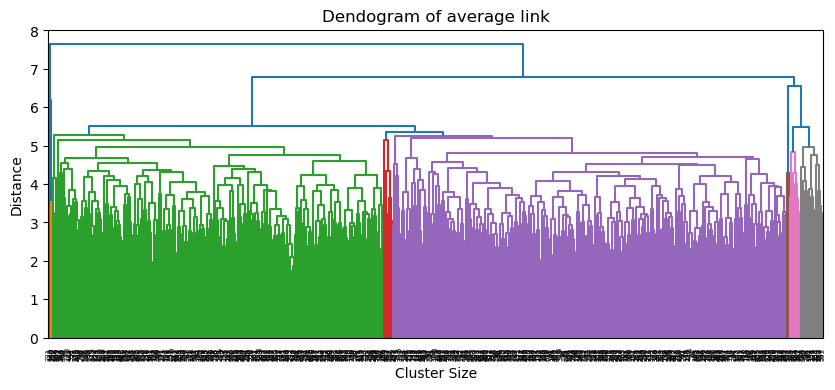

In [318]:
#this block deals with the same as KMEANS but for hierarchial clustering now

# building the 
hierarchial_pipeline = Pipeline([
    ('preprocess', combined_pipeline),
     ('densify',    FunctionTransformer(lambda X: X.toarray(),
                                       accept_sparse=True)),
    ('hierarchial', AgglomerativeClustering(n_clusters = k, linkage = 'ward'))
])

# fiting and predictting
data['cluster_hierarchial'] = hierarchial_pipeline.fit_predict(data)

# inspect cluster sizes
print(f"Cluster sizes: {data['cluster_hierarchial'].value_counts()}\n")

display(HTML('<h2>Hiararchial Results On Dataset</h2>'))
#print the rows with cluster labels
print(data[['title', 'genre', 'runtime', 'imdb_num_votes', 'cluster_hierarchial']].head())

#use our scaled pipeline for clustering
hier_cluster = combined_pipeline.fit_transform(data)
if hasattr(hier_cluster, "toarray"):
    hier_cluster = hier_cluster.toarray()

#hierarchial clustering with: Single, Complete and Average Links
methods = ['single', 'complete', 'average']

#create and show the Dendrogram for each linkage
for i in methods:
    link_matrix = linkage(hier_cluster, method = i)

    matPlot.figure(figsize=(10, 4))
    matPlot.title(f"Dendogram of {i} link")
    dendrogram(link_matrix,
               show_contracted=True)
    matPlot.xlabel("Cluster Size")
    matPlot.ylabel("Distance")
    matPlot.tight_layout
    matPlot.show()

In [319]:
display(HTML('<h3>KMEANS VS Hiararchial Results</h3>'))

#print the rows with cluster labels
print(data[['title', 'genre', 'runtime', 'cluster_kmeans', 'cluster_hierarchial']].head())

                  title   genre  runtime  cluster_kmeans  cluster_hierarchial
0           Filly Brown   Drama     80.0               3                    1
1              The Dish   Drama    101.0               1                    2
2   Waiting for Guffman  Comedy     84.0               1                    2
3  The Age of Innocence   Drama    139.0               1                    2
4           Malevolence  Horror     90.0               2                    1
